In [ ]:
# Z-score Method is only applicable for Normal dist. or near-normal dist. 
# for other distribution, this method can't detect outliers effeciently.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as pyplot 
import seaborn as sns 

In [2]:
df = pd.read_csv('placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
426,7.26,21.0,0
181,7.30,42.0,0
930,6.94,7.0,1
634,7.69,39.0,0
733,7.07,10.0,0


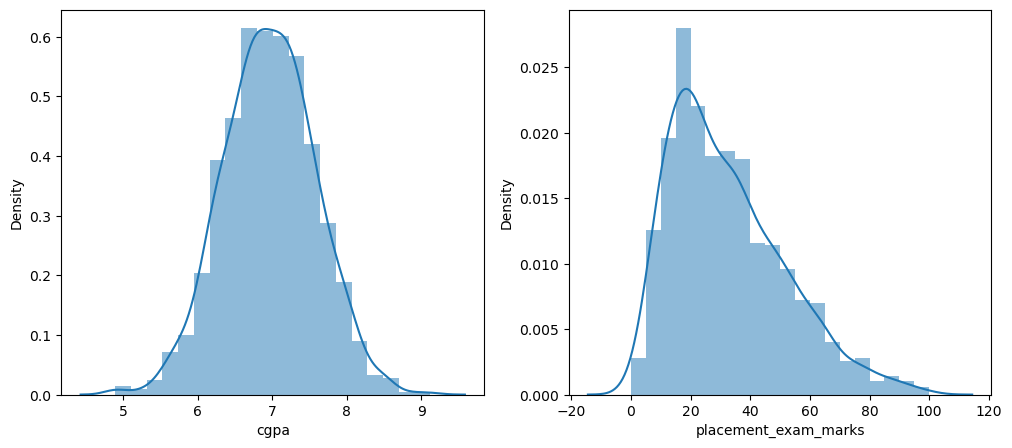

In [3]:
pyplot.figure(figsize=(12,5))
pyplot.subplot(121)
sns.histplot(x=df['cgpa'], bins=20, alpha=0.5,stat='density', linewidth=0)
sns.kdeplot(x=df['cgpa'])                     # cgpa is having near-normal Distribution

pyplot.subplot(122)
sns.histplot(x=df['placement_exam_marks'], bins=20, alpha=0.5,stat='density', edgecolor='none')
sns.kdeplot(x=df['placement_exam_marks'])     # placement_exam_marks have Right Skewed Distribution
pyplot.show()

In [4]:
df['cgpa'].describe()           # mean, std, min, max

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [5]:
# finding the boundary values of df['cgpa']   
# Z-score  :      (mean - 3*std) < val < (mean + 3*std)
print("Highest allowed val :", df['cgpa'].mean() - 3*df['cgpa'].std())
print("Lowest allowed val :", df['cgpa'].mean() + 3*df['cgpa'].std())

Highest allowed val : 5.113546374602832
Lowest allowed val : 8.808933625397168


In [7]:
# finding the Outliers 
df[(df['cgpa'] > 8.81) | (df['cgpa'] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


<h2 style='color:red'>Trimming</h2>

In [8]:
# Completely removing the outliers from the Dataset  
new_df = df[(df['cgpa'] < 8.81) & (df['cgpa'] > 5.11)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [10]:
# Approach 2 

# Calculate Z-Score for each row,  if Z-score [-3, 3] (not a outlier)
df['cgpa_zscore'] = (df['cgpa'] - df['cgpa'].mean()) / df['cgpa'].std()

In [12]:
# Rows with Outliers
df[(df['cgpa_zscore'] < -3) | (df['cgpa_zscore'] > 3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [13]:
# Trimming (completely removing outliers)
df[(df['cgpa_zscore'] >= -3) & (df['cgpa_zscore'] <= 3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


<h2 style='color:red'>Capping</h2>

In [14]:
# Capping - not let any value to go outside min to max value range without dropping them. 
upper_limit = df['cgpa'].mean() - 3*df['cgpa'].std()
lower_limit = df['cgpa'].mean() + 3*df['cgpa'].std()

In [15]:
df['cgpa'] = np.where(
        df['cgpa'] > upper_limit,                # condition
        upper_limit,                             # if true    (cgpa > upper_limit, replace df['cgpa'] value by upper_limit)
        np.where(                                # if false
                 df['cgpa'] < lower_limit,             # condition
                 lower_limit,                          # if true
                 df['cgpa']                            # if false
                )
       ) 


In [17]:
df['cgpa'].describe()

count    1000.000000
mean        5.124633
std         0.202202
min         5.113546
25%         5.113546
50%         5.113546
75%         5.113546
max         8.808934
Name: cgpa, dtype: float64